<a href="https://colab.research.google.com/github/alwhshalkasr267-design/FinalProject/blob/main/finalproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Required Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
zip_path = '/content/drive/MyDrive/Obstacles_dataset.zip'
extracted_path = '/content/dataset/Obstacles_dataset'

if not os.path.exists(extracted_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    print("تم فك ضغط البيانات بنجاح في المسار المحلي.")
else:
    print("المجلد موجود مسبقاً.")

تم فك ضغط البيانات بنجاح في المسار المحلي.


Load Data

In [4]:
folder_path = '/content/dataset/Obstacles_dataset'

if len(os.listdir(folder_path)) == 1:
    folder_path = os.path.join(folder_path, os.listdir(folder_path)[0])

classes_names = sorted(os.listdir(folder_path))
print("Dataset Classes: ", classes_names)

Dataset Classes:  ['chair', 'door', 'fence', 'garbage_bin', 'obstacle', 'plant', 'pothole', 'stairs', 'table', 'vehicle']


In [5]:
# حساب عدد الصور في كل كلاس
i = 1
for folder in sorted(os.listdir(folder_path)):
    full_folder_path = os.path.join(folder_path, folder)
    if os.path.isdir(full_folder_path):
        num_images = len(os.listdir(full_folder_path))
        print(f"{i} Number of [{folder}] Class : {num_images} images")
        i += 1

1 Number of [chair] Class : 407 images
2 Number of [door] Class : 242 images
3 Number of [fence] Class : 179 images
4 Number of [garbage_bin] Class : 175 images
5 Number of [obstacle] Class : 423 images
6 Number of [plant] Class : 139 images
7 Number of [pothole] Class : 706 images
8 Number of [stairs] Class : 504 images
9 Number of [table] Class : 185 images
10 Number of [vehicle] Class : 604 images


In [6]:
images = []
labels = []

for label_idx, classes_name in enumerate(classes_names):
    class_dir = os.path.join(folder_path, classes_name)
    if os.path.isdir(class_dir):
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            images.append(img_path)
            labels.append(str(label_idx))

In [7]:
df = pd.DataFrame({
    "image": images,
    "label": labels
})

# خلط البيانات
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total images collected: {len(df)}")
df.head()

Total images collected: 3564


,image,label
0,/content/dataset/Obstacles_dataset/Obstacles_d...,7
1,/content/dataset/Obstacles_dataset/Obstacles_d...,0
2,/content/dataset/Obstacles_dataset/Obstacles_d...,6
3,/content/dataset/Obstacles_dataset/Obstacles_d...,4
4,/content/dataset/Obstacles_dataset/Obstacles_d...,8


In [8]:
# تنظيف الصور طبعا الصور عندي نظيفة هشغل الكود فقط عند اخر نقطة
from PIL import Image
from tqdm import tqdm

bad = []

for p in tqdm(df["image"]):
  try:
    with Image.open(p) as im:
      im.load()
  except:
    bad.append(p)

print("Bad images : ", len(bad))

df = df[~df["image"].isin(bad)].reset_index(drop=True)
print("Remaining images : ", len(df) )

100%|██████████| 3564/3564 [00:06<00:00, 549.76it/s]

Bad images :  0
Remaining images :  3564


In [9]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train: ", len(train_df))
print(f"Validation: {len(val_df)}")
print("Test: ", len(test_df))

Train:  2494
Validation: 535
Test:  535


In [10]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_it = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_it = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2494 validated image filenames belonging to 10 classes.
Found 535 validated image filenames belonging to 10 classes.


In [12]:
from sklearn.utils import class_weight

train_classes = train_it.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights))
print("الأوزان المحسوبة للكلاسات:\n", class_weights_dict)

الأوزان المحسوبة للكلاسات:
 {0: np.float64(0.8750877192982456), 1: np.float64(1.475739644970414), 2: np.float64(1.9952), 3: np.float64(2.0276422764227644), 4: np.float64(0.8425675675675676), 5: np.float64(2.571134020618557), 6: np.float64(0.5048582995951417), 7: np.float64(0.7065155807365439), 8: np.float64(1.9333333333333333), 9: np.float64(0.5895981087470449)}


In [13]:
model = models.Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(len(classes_names), activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,641,834 (13.89 MB)

 Trainable params: 3,640,074 (13.89 MB)

 Non-trainable params: 1,760 (6.88 KB)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,                 # زدنا الـ patience قليلاً لأن النموذج من الصفر يحتاج وقت أطول للاستقرار
    restore_best_weights=True
)

checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# تقليل الـ Learning Rate تلقائياً عند ثبات الأداء لضمان دقة أعلى وسلاسة في المنحنى
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [16]:
history = model.fit(
    train_it,
    epochs=35,
    validation_data=test_it,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, checkpoint_callback ,lr_reducer] # دمجنا الوظيفتين هنا داخل القائمة
)

Epoch 1/35
24/78 ━━━━━━━━━━━━━━━━━━━━ 2:03 2s/step - accuracy: 0.8652 - loss: 0.3972

KeyboardInterrupt: 

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 740ms/step - accuracy: 0.8411 - loss: 0.5114

🎯 Final Test Accuracy: 84.11%

17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 468ms/step
Detailed Classification Report:
              precision    recall  f1-score   support

       chair       0.70      0.74      0.72        61
        door       0.81      0.95      0.88        37
       fence       0.92      0.85      0.88        27
 garbage_bin       0.72      0.88      0.79        26
    obstacle       0.94      0.75      0.83        63
       plant       0.80      0.95      0.87        21
     pothole       0.83      0.95      0.89       106
      stairs       0.89      0.76      0.82        76
       table       0.74      0.82      0.78        28
     vehicle       0.95      0.83      0.89        90

    accuracy                           0.84       535
   macro avg       0.83      0.85      0.84       535
weighted avg       0.85      0.84      0.84       535



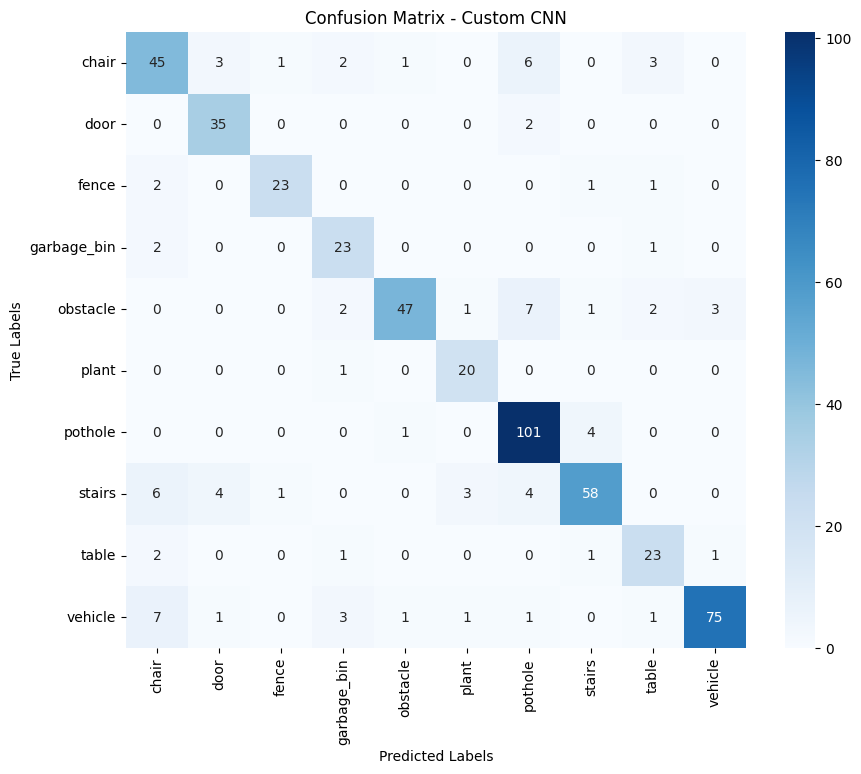

In [17]:
test_loss, test_acc = model.evaluate(test_it)
print(f"\n🎯 Final Test Accuracy: {test_acc*100:.2f}%\n")

predictions = model.predict(test_it)
y_pred = np.argmax(predictions, axis=1)
y_true = test_it.classes

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes_names))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Custom CNN')
plt.show()